In [1]:
"""
End-to-end pipeline:
A) Simulated power curve for state-year TWFE DiD toy design (pre 2006-10, post 2011-13)
B) LLM-generated "bridge program" mapping budget/enrollment scale -> implied mortality effect beta_pop
C) Compile+audit bridge program, then plot:
   - Power vs deltaB (annual incremental outlays)
   - Power vs deltaN (annual incremental enrollment)

Conventions:
- beta_frac is a FRACTION (0.03 means 3% mortality reduction)
- MDE is reported in PERCENT units from the power curve; we convert to FRACTION when needed

Requires:
pip install numpy pandas matplotlib scipy python-dotenv openai pydantic sympy
"""

from __future__ import annotations

import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field
import sympy as sp


# =============================================================================
# A) POWER SIMULATION (toy design)
# =============================================================================

DATA_PATH = "Multiple Cause of Death, 1999-2020.csv"

N_SIM = 500
N_TREATED = 23

FIRST_YEAR, LAST_YEAR = 2006, 2011          # pre: 2006-2010, post: 2011-2013
EFFECT_GRID = np.arange(0, 0.05001, 0.0025) # 0% to 5% by 0.25% (fraction grid)
ALPHAS = [0.10, 0.05, 0.01, 0.001]
TARGET_POWER = 80.0
ALPHA_FOR_MDE = 0.05

rng = np.random.default_rng(1234)

print("Loading mortality data:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df[df["year"].notna()].copy()
df["year"] = df["year"].astype(int)

df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df = df.dropna(subset=["deaths", "population"])

# keep pseudo-design window and pre-ACA years
df = df[(df["year"] >= FIRST_YEAR) & (df["year"] < 2014)].copy()
df["state_id"] = pd.to_numeric(df["state_code"], errors="coerce").astype(int)

# indices for fast group ops
state_codes = np.sort(df["state_id"].unique())
year_vals = np.sort(df["year"].unique())
state_to_idx = {s:i for i,s in enumerate(state_codes)}
year_to_idx  = {y:i for i,y in enumerate(year_vals)}

s = df["state_id"].map(state_to_idx).to_numpy()
tt = df["year"].map(year_to_idx).to_numpy()
S, T = len(state_codes), len(year_vals)

deaths0 = df["deaths"].to_numpy().astype(int)
pop = df["population"].to_numpy().astype(float)
w = pop
post = (df["year"].to_numpy() >= LAST_YEAR).astype(int)

def twoway_demean(x: np.ndarray) -> np.ndarray:
    x_bar = (w * x).sum() / w.sum()
    xs = np.bincount(s, weights=w * x, minlength=S) / np.bincount(s, weights=w, minlength=S)
    xt = np.bincount(tt, weights=w * x, minlength=T) / np.bincount(tt, weights=w, minlength=T)
    return x - xs[s] - xt[tt] + x_bar

def twfe_beta_se(y: np.ndarray, d: np.ndarray):
    yt = twoway_demean(y)
    dt = twoway_demean(d)

    bread = np.sum(w * dt * dt)
    beta = np.sum(w * dt * yt) / bread

    u = yt - beta * dt
    score_g = np.bincount(s, weights=(w * dt * u), minlength=S)
    var_beta = np.sum(score_g**2) / (bread**2)

    return beta, np.sqrt(var_beta), (S - 1)

# simulate p-values for each effect size
J = len(EFFECT_GRID)
pvals = np.empty((N_SIM, J))
state_idx = np.arange(S)

print(f"Simulating power: N_SIM={N_SIM}, effect grid size={J} ...")
for k in range(N_SIM):
    treated_states = rng.choice(state_idx, size=N_TREATED, replace=False)
    treated = np.isin(s, treated_states).astype(int)
    d = treated * post  # TreatPost regressor

    for j, eff in enumerate(EFFECT_GRID):
        removed = rng.binomial(n=deaths0, p=eff) * d
        deaths_eff = deaths0 - removed
        y = np.log((deaths_eff / pop) * 100000.0 + 1.0)

        beta, se_beta, df_t = twfe_beta_se(y, d)

        # nlcom 100*(exp(beta)-1) but we only need p-values.
        b_pct = 100.0 * (np.exp(beta) - 1.0)
        se_pct = 100.0 * np.exp(beta) * se_beta
        tstat = b_pct / se_pct
        pvals[k, j] = 2 * t.sf(np.abs(tstat), df=df_t)

    if (k + 1) % 25 == 0:
        print(f"Completed {k+1}/{N_SIM}")

# power table: x-axis in percent
out = pd.DataFrame({"effect_size_pct": EFFECT_GRID * 100})
for a in ALPHAS:
    out[f"power_{a:.3f}"] = (pvals <= a).mean(axis=0) * 100

def mde_from_power_curve(out: pd.DataFrame, alpha=0.05, target_power=80.0) -> float:
    col = f"power_{alpha:.3f}"
    gap = np.abs(out[col] - target_power)
    i1, i2 = np.argsort(gap.values)[:2]
    x1, x2 = out.loc[[i1, i2], "effect_size_pct"].values
    y1, y2 = out.loc[[i1, i2], col].values
    m = (y2 - y1) / (x2 - x1)
    b0 = y1 - m * x1
    return float((target_power - b0) / m)  # percent units

mde_sim_pct = mde_from_power_curve(out, alpha=ALPHA_FOR_MDE, target_power=TARGET_POWER)
print(f"Simulated MDE ≈ {mde_sim_pct:.3f}% (alpha={ALPHA_FOR_MDE}, target power={TARGET_POWER}%)")

def power_at_effect(out: pd.DataFrame, alpha: float, effect_pct: float) -> float:
    col = f"power_{alpha:.3f}"
    return float(np.interp(effect_pct, out["effect_size_pct"].values, out[col].values))


# =============================================================================
# B*) CBO SERIES: build cbo_july + cbo_feb with consistent column names
# =============================================================================

years = np.arange(2012, 2023)

# July 2012 Table 3 (calendar year): TOTAL nonelderly pop (millions), ΔN Medicaid+CHIP under ACA (millions)
N_pop_m = np.array([269,271,272,274,275,277,280,280,282,283,284], dtype=float)
dN_m    = np.array([0,  1,  7,  9, 10, 10, 11, 11, 11, 11, 11], dtype=float)

# July 2012 Table 4 (fiscal year): ΔB Medicaid+CHIP outlays attributable to coverage provisions (billions)
dB_bil  = np.array([-1, 1, 26, 49, 62, 69, 77, 83, 86, 92, 99], dtype=float)

cbo_july = pd.DataFrame({
    "year": years,
    "N_pop": N_pop_m * 1e6,
    "dN": dN_m * 1e6,
    "dB": dB_bil * 1e9
})

# Baseline shift at 2012 for rel series (what your plots use)
dN0 = float(cbo_july.loc[cbo_july.year == 2012, "dN"].iloc[0])
dB0 = float(cbo_july.loc[cbo_july.year == 2012, "dB"].iloc[0])
cbo_july["dN_rel"] = cbo_july["dN"] - dN0
cbo_july["dB_rel"] = cbo_july["dB"] - dB0

# --- Feb 2013 update (approximate annual series via scaling) ---
# Your earlier convention:
# - Medicaid/CHIP coverage in 2022: 11M (July profile) -> 12M (Feb)
# - 10-year outlays (2013-2022 total): 643B (Aug) -> 550B (Feb)
dN2022_feb = 12e6
dB10_feb = 550e9

mask_2013_2022 = (cbo_july["year"] >= 2013) & (cbo_july["year"] <= 2022)

scale_dN_feb = dN2022_feb / float(cbo_july.loc[cbo_july.year == 2022, "dN"].iloc[0])
scale_dB_feb = dB10_feb / float(cbo_july.loc[mask_2013_2022, "dB"].sum())

cbo_feb = cbo_july.copy()
cbo_feb["dN"] = scale_dN_feb * cbo_feb["dN"]
cbo_feb.loc[mask_2013_2022, "dB"] = scale_dB_feb * cbo_feb.loc[mask_2013_2022, "dB"]

# Recompute rel series for Feb
dN0_f = float(cbo_feb.loc[cbo_feb.year == 2012, "dN"].iloc[0])
dB0_f = float(cbo_feb.loc[cbo_feb.year == 2012, "dB"].iloc[0])
cbo_feb["dN_rel"] = cbo_feb["dN"] - dN0_f
cbo_feb["dB_rel"] = cbo_feb["dB"] - dB0_f

# Convenience
N_pop_2022 = float(cbo_july.loc[cbo_july.year == 2022, "N_pop"].iloc[0])



Loading mortality data: Multiple Cause of Death, 1999-2020.csv
Simulating power: N_SIM=500, effect grid size=21 ...
Completed 25/500
Completed 50/500
Completed 75/500
Completed 100/500
Completed 125/500
Completed 150/500
Completed 175/500
Completed 200/500
Completed 225/500
Completed 250/500
Completed 275/500
Completed 300/500
Completed 325/500
Completed 350/500
Completed 375/500
Completed 400/500
Completed 425/500
Completed 450/500
Completed 475/500
Completed 500/500
Simulated MDE ≈ 3.183% (alpha=0.05, target power=80.0%)


In [2]:
# =============================================================================
# C) LM BRIDGE GENERATOR / COMPILER  (UPDATED: stable parameter interface)
# =============================================================================

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field
import sympy as sp
import os

load_dotenv()
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

class BridgeProgram(BaseModel):
    bridge_id: str
    beta_frac_from_deltaB: str = Field(...)
    beta_frac_from_deltaN: str = Field(...)
    parameters: list[dict[str, object]] = Field(default_factory=list)
    comments: str = ""

class BridgeResponse(BaseModel):
    programs: list[BridgeProgram]

BridgeResponse.model_rebuild()

# ---- Key design choice: allow ONLY these extra parameters (stable across runs) ----
ALLOWED_PARAMS = {"c", "kappa"}
ENDPOINTS = {"deltaB", "deltaN", "N_pop", "MDE", "beta"}
ALLOWED_SYMBOLS = ENDPOINTS | ALLOWED_PARAMS

PROMPT_TEMPLATE = r"""
You are a formal-methods assistant.

We have endpoints:
- deltaB: incremental federal outlays (dollars) [annual object]
- deltaN: incremental Medicaid+CHIP enrollment (persons) [annual object]
- N_pop: analysis population size (persons)
- beta: population proportional mortality effect (FRACTION units: 0.03 = 3%)

Goal: Propose bridge programs mapping (deltaB, deltaN, N_pop) -> beta.

CRITICAL CONSTRAINT:
- You may introduce AT MOST TWO free parameters beyond the endpoints, and they MUST be named exactly:
  (1) c     = dollars per person-year (dollars/person-year)
  (2) kappa = unitless health-channel parameter
- Do NOT introduce any other free symbols besides: deltaB, deltaN, N_pop, beta, c, kappa.
  (No gamma, phi, cost_per_enrollee, etc.)

Return exactly 2 programs. Each program must provide:
- bridge_id
- beta_frac_from_deltaB: a sympy expression using ONLY (deltaB, N_pop, c, kappa) and returning beta as a FRACTION
- beta_frac_from_deltaN: a sympy expression using ONLY (deltaN, N_pop, kappa) and returning beta as a FRACTION
- parameters: list containing entries for c and kappa (with units and descriptions). Default can be null.
- comments

Allowed reasoning moves:
- accounting identity deltaN = deltaB / c (annual object)
- dilution mapping beta = (deltaN/N_pop) * kappa

Do NOT use general equilibrium or health production functions.

Return ONLY valid JSON matching exactly this template:

{
  "programs": [
    {
      "bridge_id": "string",
      "beta_frac_from_deltaB": "string sympy expr",
      "beta_frac_from_deltaN": "string sympy expr",
      "parameters": [
        {"name":"c","unit":"dollars/person-year","description":"...","default": null},
        {"name":"kappa","unit":"unitless","description":"...","default": null}
      ],
      "comments": "string"
    },
    {
      "bridge_id": "string",
      "beta_frac_from_deltaB": "string sympy expr",
      "beta_frac_from_deltaN": "string sympy expr",
      "parameters": [
        {"name":"c","unit":"dollars/person-year","description":"...","default": null},
        {"name":"kappa","unit":"unitless","description":"...","default": null}
      ],
      "comments": "string"
    }
  ]
}
"""

def _validate_bridge_json(raw: str) -> BridgeResponse:
    return BridgeResponse.model_validate_json(raw)

def call_lm_bridge(run_id: int, temperature: float = 0.3, do_repair: bool = True):
    prompt = PROMPT_TEMPLATE + f"\n\n(bridge_generation_run_id={run_id})"

    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "system", "content": "Output ONLY valid JSON matching the template. No markdown."},
            {"role": "user", "content": prompt},
        ],
        temperature=temperature,
    )
    raw = resp.choices[0].message.content

    try:
        return _validate_bridge_json(raw), raw
    except Exception:
        if not do_repair:
            raise

        os.makedirs("bridge_cache", exist_ok=True)
        with open(f"bridge_cache/bad_bridge_run{run_id}.txt", "w", encoding="utf-8") as f:
            f.write(raw)

        repair_prompt = f"""
Reformat into VALID JSON matching exactly this template:

{{
  "programs": [
    {{
      "bridge_id": "...",
      "beta_frac_from_deltaB": "...",
      "beta_frac_from_deltaN": "...",
      "parameters": [
        {{"name":"c","unit":"dollars/person-year","description":"...","default": null}},
        {{"name":"kappa","unit":"unitless","description":"...","default": null}}
      ],
      "comments": "..."
    }},
    {{
      "bridge_id": "...",
      "beta_frac_from_deltaB": "...",
      "beta_frac_from_deltaN": "...",
      "parameters": [
        {{"name":"c","unit":"dollars/person-year","description":"...","default": null}},
        {{"name":"kappa","unit":"unitless","description":"...","default": null}}
      ],
      "comments": "..."
    }}
  ]
}}

Output ONLY the corrected JSON.

CONTENT:
{raw}
"""
        resp2 = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[
                {"role":"system","content":"Output ONLY valid JSON. No markdown."},
                {"role":"user","content":repair_prompt},
            ],
            temperature=0.0,
        )
        raw2 = resp2.choices[0].message.content
        return _validate_bridge_json(raw2), raw2


# ---- Sympy compile / audit helpers ----
def compile_expr(expr: str):
    sym = {
        "deltaB": sp.Symbol("deltaB", real=True),
        "deltaN": sp.Symbol("deltaN", real=True),
        "N_pop":  sp.Symbol("N_pop", real=True),
        "beta":   sp.Symbol("beta", real=True),
        "MDE":    sp.Symbol("MDE", real=True),
        "c":      sp.Symbol("c", real=True),
        "kappa":  sp.Symbol("kappa", real=True),
    }
    e = sp.sympify(expr, locals=sym)
    return sym, e

def required_symbols(expr: sp.Expr) -> list[str]:
    return sorted([str(s) for s in expr.free_symbols])

def make_callable(expr_str: str, required: list[str]):
    sym, e = compile_expr(expr_str)
    lmb = sp.lambdify([sym[x] for x in required], e, "numpy")

    def fn(**kwargs):
        missing = [x for x in required if x not in kwargs]
        if missing:
            raise KeyError(f"Missing args {missing}; required={required}")
        return float(lmb(*[kwargs[x] for x in required]))

    return fn

def audit_bridge_program(p: BridgeProgram):
    _, eB = compile_expr(p.beta_frac_from_deltaB)
    _, eN = compile_expr(p.beta_frac_from_deltaN)

    freeB = set(required_symbols(eB))
    freeN = set(required_symbols(eN))

    # Must include these endpoints
    if "deltaB" not in freeB or "N_pop" not in freeB:
        raise ValueError("beta_frac_from_deltaB must depend on deltaB and N_pop.")
    if "deltaN" not in freeN or "N_pop" not in freeN:
        raise ValueError("beta_frac_from_deltaN must depend on deltaN and N_pop.")

    # Must not introduce unknown symbols
    extra = (freeB | freeN) - ALLOWED_SYMBOLS
    if extra:
        raise ValueError(f"Bridge uses disallowed symbols: {sorted(extra)}")

    # Ensure declared parameters cover c and kappa (optional but nice)
    declared = {d.get("name") for d in p.parameters} if p.parameters else set()
    missing_decl = [x for x in ["c","kappa"] if x not in declared]

    return sorted(list((freeB | freeN) - ENDPOINTS)), missing_decl

def default_param_values(p: BridgeProgram) -> dict[str, float]:
    vals: dict[str, float] = {}
    for d in p.parameters:
        if "default" in d and d["default"] is not None:
            vals[d["name"]] = float(d["default"])
    return vals

In [3]:
# =============================================================================
# D) Run multiple LM bridge generations; compile (UPDATED)
# =============================================================================

R = 4
os.makedirs("bridge_cache", exist_ok=True)

bridges = []
for r in range(1, R+1):
    pkg, raw = call_lm_bridge(run_id=r, temperature=0.35, do_repair=True)

    with open(f"bridge_cache/bridge_programs_run{r}.json", "w", encoding="utf-8") as f:
        f.write(raw)

    for prog in pkg.programs:
        try:
            params, missing_decl = audit_bridge_program(prog)

            _, eB = compile_expr(prog.beta_frac_from_deltaB)
            _, eN = compile_expr(prog.beta_frac_from_deltaN)

            argsB = ["deltaB", "N_pop", "c", "kappa"]  # fixed interface
            argsN = ["deltaN", "N_pop", "kappa"]       # fixed interface

            beta_from_B = make_callable(prog.beta_frac_from_deltaB, argsB)
            beta_from_N = make_callable(prog.beta_frac_from_deltaN, argsN)

            bridges.append({
                "run_id": r,
                "bridge_id": prog.bridge_id,
                "prog": prog,
                "params": params,
                "missing_decl": missing_decl,
                "beta_from_B": beta_from_B,
                "beta_from_N": beta_from_N,
                "argsB": argsB,
                "argsN": argsN,
                "defaults": default_param_values(prog),
            })

            print(f"[run {r}] bridge={prog.bridge_id} params={params} missing_decl={missing_decl}")

        except Exception as e:
            print(f"[run {r}] SKIP bridge due to audit error: {e}")

print(f"Total bridge programs compiled: {len(bridges)}")

# Now your plotting section can be stable:
USER_PARAM_OVERRIDES = {"c": 6000.0, "kappa": 0.10}

def assemble_kwargs(required_args: list[str], base: dict[str, float], defaults: dict[str, float], overrides: dict[str, float]) -> dict[str, float]:
    outk: dict[str, float] = {}
    for a in required_args:
        if a in base:
            outk[a] = base[a]
        elif a in overrides:
            outk[a] = overrides[a]
        elif a in defaults:
            outk[a] = defaults[a]
        else:
            raise KeyError(f"Missing value for required bridge parameter '{a}'. Provide in USER_PARAM_OVERRIDES.")
    return outk

[run 1] bridge=direct_dilution params=['c', 'kappa'] missing_decl=[]
[run 1] bridge=enrollment_first params=['c', 'kappa'] missing_decl=[]
[run 2] bridge=direct_dilution params=['c', 'kappa'] missing_decl=[]
[run 2] bridge=enrollment_first params=['c', 'kappa'] missing_decl=[]
[run 3] bridge=direct_dilution params=['c', 'kappa'] missing_decl=[]
[run 3] bridge=enrollment_based params=['c', 'kappa'] missing_decl=[]
[run 4] bridge=direct_dilution params=['c', 'kappa'] missing_decl=[]
[run 4] bridge=enrollment_first params=['c', 'kappa'] missing_decl=[]
Total bridge programs compiled: 8


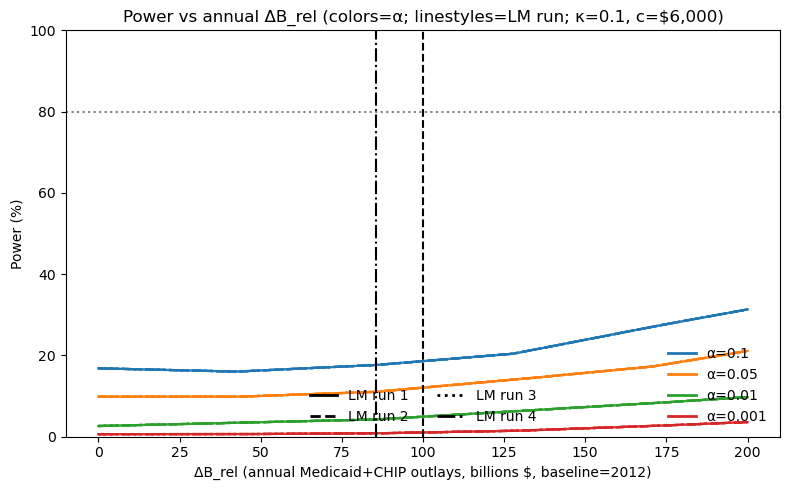

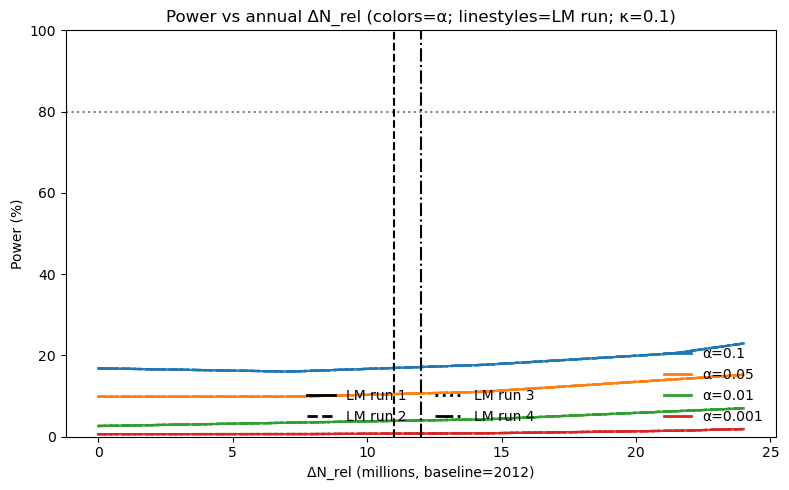


Done. Inspect bridge_cache/bridge_programs_run*.json for audited provenance.
If you see KeyError about missing parameters, add them to USER_PARAM_OVERRIDES or tighten the LM prompt.


In [4]:

# =============================================================================
# E) Plots: power vs ΔB_rel and power vs ΔN_rel
#     - colors = alpha
#     - linestyles = LM run
# =============================================================================

# --- scenario (these matter) ---
# If LM bridges include c/kappa or equivalents, you must set them here or via defaults.
USER_PARAM_OVERRIDES = {
    "c": 6000.0,
    "kappa": 0.10,
}

# Build grids for x-axes using observed CBO ranges (scaled)
dB_grid = np.linspace(0, float(cbo_july["dB_rel"].max()*2), 200)
dN_grid = np.linspace(0, float(cbo_feb["dN_rel"].max()*2), 200)

# We will plot for multiple alphas, like your original figure
alpha_list = ALPHAS

# Styling
alpha_colors = {a: c for a, c in zip(alpha_list, ["C0", "C1", "C2", "C3"])}
run_linestyles = {
    1: "solid",
    2: "dashed",
    3: "dotted",
    4: "dashdot",
    5: (0, (3, 1, 1, 1)),  # optional if you run more than 4
}

def assemble_kwargs(required_args, base, defaults, overrides):
    outk = {}
    for a in required_args:
        if a in base:
            outk[a] = base[a]
        elif a in overrides:
            outk[a] = overrides[a]
        elif a in defaults:
            outk[a] = defaults[a]
        else:
            raise KeyError(
                f"Missing value for required bridge parameter '{a}'. "
                f"Required args={required_args}. Provide in USER_PARAM_OVERRIDES "
                f"or force LM to supply defaults."
            )
    return outk

def plot_power_vs_deltaB_rel():
    plt.figure(figsize=(8, 5))

    for b in bridges:
        ls = run_linestyles.get(b["run_id"], "solid")

        for a in alpha_list:
            pw = []
            for x in dB_grid:
                base = {"deltaB": x, "N_pop": N_pop_2022}
                kwargs = assemble_kwargs(b["argsB"], base, b["defaults"], USER_PARAM_OVERRIDES)

                beta_frac = b["beta_from_B"](**kwargs)   # FRACTION (0.03=3%)
                beta_pct = 100.0 * abs(beta_frac)        # convert to percent for power lookup

                pw.append(power_at_effect(out, a, beta_pct))

            # plot: color=alpha, linestyle=run
            plt.plot(dB_grid/1e9, pw, lw=1.6, color=alpha_colors[a], linestyle=ls, alpha=0.75)

    # Reference lines
    plt.axhline(TARGET_POWER, color="gray", ls=":", lw=1.5, label=f"{TARGET_POWER:.0f}% power")
    plt.axvline(float(cbo_july.loc[cbo_july.year == 2022, "dB_rel"].iloc[0]) / 1e9,
                color="black", ls="--", lw=1.5, label="2022 ΔB_rel (July)")
    plt.axvline(float(cbo_feb.loc[cbo_feb.year == 2022, "dB_rel"].iloc[0]) / 1e9,
                color="black", ls="-.", lw=1.5, label="2022 ΔB_rel (Feb-scaled)")

    plt.ylim(0, 100)
    plt.xlabel("ΔB_rel (annual Medicaid+CHIP outlays, billions $, baseline=2012)")
    plt.ylabel("Power (%)")
    plt.title(f"Power vs annual ΔB_rel (colors=α; linestyles=LM run; κ={USER_PARAM_OVERRIDES.get('kappa','?')}, c=${USER_PARAM_OVERRIDES.get('c','?'):,.0f})")

    # Two legends: one for alpha colors, one for run linestyles
    alpha_handles = [plt.Line2D([0],[0], color=alpha_colors[a], lw=2, label=f"α={a:g}") for a in alpha_list]
    run_ids = sorted(set(b["run_id"] for b in bridges))
    run_handles = [plt.Line2D([0],[0], color="black", lw=2, linestyle=run_linestyles.get(r,"solid"), label=f"LM run {r}")
                   for r in run_ids]

    leg1 = plt.legend(handles=alpha_handles, frameon=False, loc="lower right")
    plt.gca().add_artist(leg1)
    plt.legend(handles=run_handles, frameon=False, loc="lower center", ncols=2)

    plt.tight_layout()
    plt.show()

def plot_power_vs_deltaN_rel():
    plt.figure(figsize=(8, 5))

    for b in bridges:
        ls = run_linestyles.get(b["run_id"], "solid")

        for a in alpha_list:
            pw = []
            for x in dN_grid:
                base = {"deltaN": x, "N_pop": N_pop_2022}
                kwargs = assemble_kwargs(b["argsN"], base, b["defaults"], USER_PARAM_OVERRIDES)

                beta_frac = b["beta_from_N"](**kwargs)
                beta_pct = 100.0 * abs(beta_frac)

                pw.append(power_at_effect(out, a, beta_pct))

            plt.plot(dN_grid/1e6, pw, lw=1.6, color=alpha_colors[a], linestyle=ls, alpha=0.75)

    plt.axhline(TARGET_POWER, color="gray", ls=":", lw=1.5, label=f"{TARGET_POWER:.0f}% power")
    plt.axvline(float(cbo_july.loc[cbo_july.year == 2022, "dN_rel"].iloc[0]) / 1e6,
                color="black", ls="--", lw=1.5, label="2022 ΔN_rel (July)")
    plt.axvline(float(cbo_feb.loc[cbo_feb.year == 2022, "dN_rel"].iloc[0]) / 1e6,
                color="black", ls="-.", lw=1.5, label="2022 ΔN_rel (Feb-scaled)")

    plt.ylim(0, 100)
    plt.xlabel("ΔN_rel (millions, baseline=2012)")
    plt.ylabel("Power (%)")
    plt.title(f"Power vs annual ΔN_rel (colors=α; linestyles=LM run; κ={USER_PARAM_OVERRIDES.get('kappa','?')})")

    alpha_handles = [plt.Line2D([0],[0], color=alpha_colors[a], lw=2, label=f"α={a:g}") for a in alpha_list]
    run_ids = sorted(set(b["run_id"] for b in bridges))
    run_handles = [plt.Line2D([0],[0], color="black", lw=2, linestyle=run_linestyles.get(r,"solid"), label=f"LM run {r}")
                   for r in run_ids]

    leg1 = plt.legend(handles=alpha_handles, frameon=False, loc="lower right")
    plt.gca().add_artist(leg1)
    plt.legend(handles=run_handles, frameon=False, loc="lower center", ncols=2)

    plt.tight_layout()
    plt.show()

# Run both figures
plot_power_vs_deltaB_rel()
plot_power_vs_deltaN_rel()

print("\nDone. Inspect bridge_cache/bridge_programs_run*.json for audited provenance.")
print("If you see KeyError about missing parameters, add them to USER_PARAM_OVERRIDES or tighten the LM prompt.")